<h1>Visualising Sentinel-3 daily statistics</h1>

<p>From JSON files derived from SEN3_download.ipynb</p>

In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from datetime import datetime

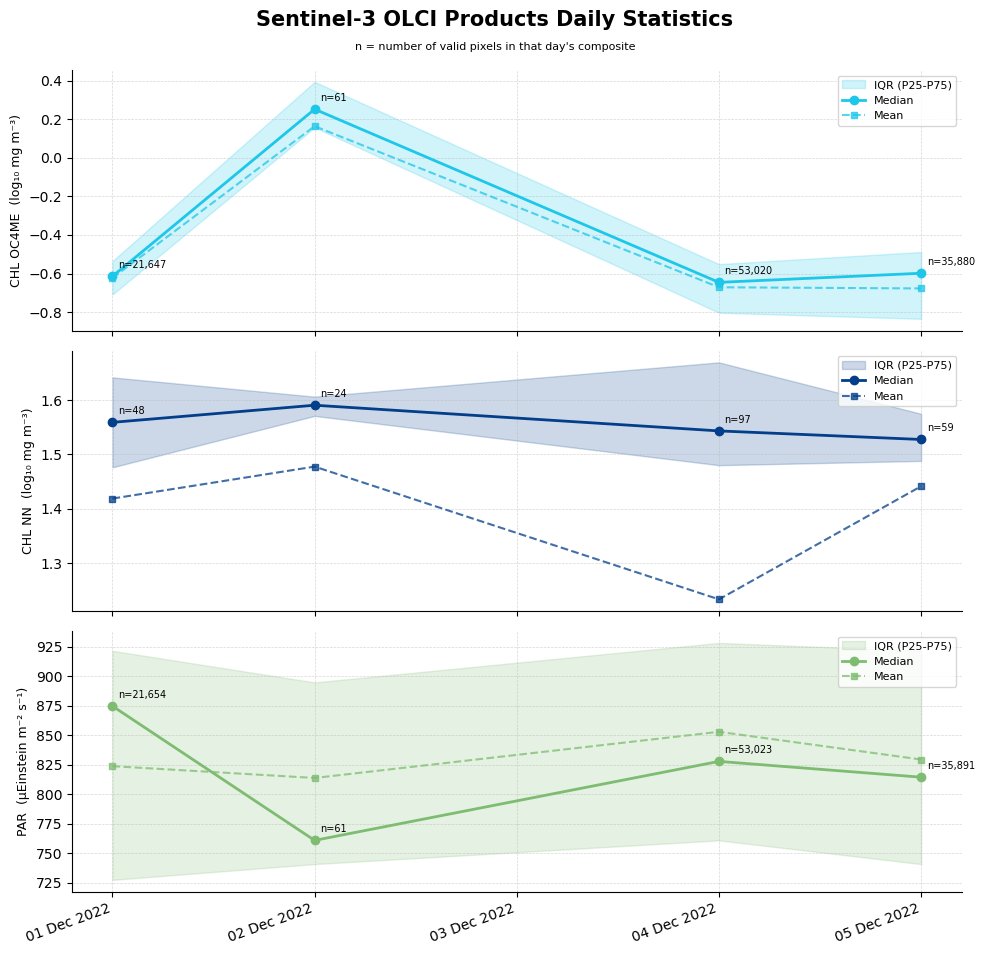

In [ ]:
data = json.load(open("/Users/gwyneth/Desktop/Masters_Thesis/LEVEL_1_PROCESSED/Sentinel3/jsons_dailystats/SEN3_daily_stats.json"))

dates = [datetime.strptime(d, "%Y-%m-%d") for d in data]
products = ["CHL_OC4ME", "CHL_NN", "PAR"]

labels = {
    "CHL_OC4ME": "CHL OC4ME (log₁₀ mg m⁻³)",
    "CHL_NN": "CHL NN (log₁₀ mg m⁻³)",
    "PAR": "PAR (μEinstein m⁻² s⁻¹)",
}
colors = {
    "CHL_OC4ME": "#1dc7e9",
    "CHL_NN": "#023e8a",
    "PAR": "#7dbc71",
}

series = {p: {k: [] for k in ("mean", "median", "p25", "p75", "n_pixels")} for p in products}
for date_str, day in data.items():
    for p in products:
        for k in ("mean", "median", "p25", "p75", "n_pixels"):
            series[p][k].append(day[p][k])

# plotting chart

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
fig.suptitle("Sentinel-3 OLCI Products Daily Statistics", fontsize=15, fontweight="bold", y=0.98)
# note explaining bubble size
fig.text(
    0.5, 0.94,
    "n = number of valid pixels in that day's composite",
    ha="center", fontsize=8, color="black",
)

for ax, p in zip(axes, products):
    color = colors[p]
    med = np.array(series[p]["median"])
    mn = np.array(series[p]["mean"])
    p25 = np.array(series[p]["p25"])
    p75 = np.array(series[p]["p75"])
    npx = np.array(series[p]["n_pixels"])

    # inter-quartile range band
    ax.fill_between(dates, p25, p75, alpha=0.20, color=color, label="IQR (P25-P75)")

    # median and mean lines
    ax.plot(dates, med, color=color, linewidth=2.0, marker="o", markersize=6, label="Median")
    ax.plot(dates, mn,  color=color, linewidth=1.5, marker="s", markersize=5,
            linestyle="--", alpha=0.75, label="Mean")

    # n_pixels as secondary annotation (scaled dot size)
    sizes = (npx / npx.max()) * 120 + 20

    ax.set_ylabel(labels[p], fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

    # annotate n_pixels
    for d, m, n in zip(dates, med, npx):
        ax.annotate(f"n={n:,}", xy=(d, m), xytext=(4, 6),
                    textcoords="offset points", fontsize=7, color="black")
    
# X-axis formatting
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
axes[-1].xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=20, ha="right")

fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig("/Users/gwyneth/Desktop/Masters_Thesis/LEVEL_2_VISUALISATION/SEN3_dailystats.png", dpi=150, bbox_inches="tight")
plt.show()